# Scenario: Evaluating Daily Sales Against Historical Benchmark

### Business Context:
A local bookstore, ReadMore, wants to know whether the average number of items sold per day during the last month meets their historical target of 50 items/day. The manager wants to understand if promotions or seasonal effects have changed daily sales.

Data Provided: daily_sales.csv
Columns: Day (date), Items_Sold (number of items sold on that day)

Goal:
Determine if daily sales are significantly different from the historical target using inferential statistics.

## Step 1: Understand the Data Type

Items_Sold: Continuous (discrete but numeric for analysis)

Analytical Question:

`“Is the daily sales average significantly different from 50 items/day?”`

### What kind of distribution and test would you tend towards given the information?


## Step 2: Explore the Distribution


In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import numpy as np

In [15]:
df = pd.read_csv("data/daily_sales.csv")

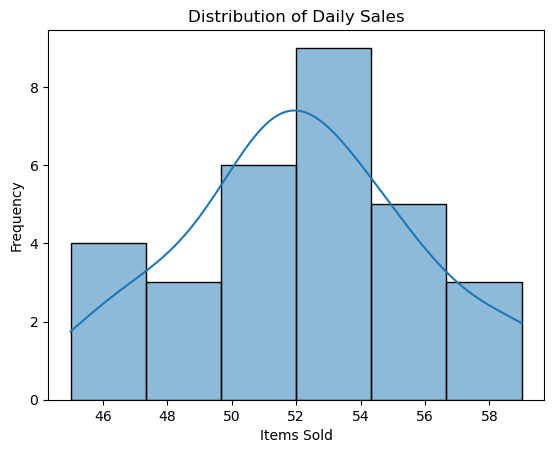

In [16]:
# Histogram
sns.histplot(df['Items_Sold'], kde=True)
plt.title("Distribution of Daily Sales")
plt.xlabel("Items Sold")
plt.ylabel("Frequency")
plt.show()

In [17]:
# Summary statistics
print(df['Items_Sold'].describe())

count    30.000000
mean     52.166667
std       3.667973
min      45.000000
25%      51.000000
50%      52.000000
75%      54.750000
max      59.000000
Name: Items_Sold, dtype: float64


### Step 2a: Check Normality Using Q-Q Plot

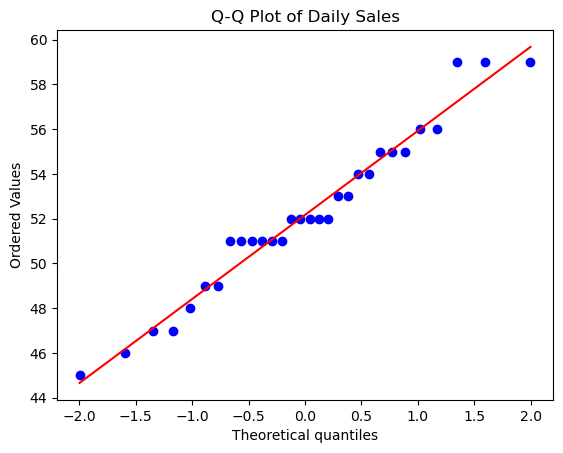

In [18]:
stats.probplot(df['Items_Sold'], dist="norm", plot=plt)
plt.title("Q-Q Plot of Daily Sales")
plt.show()

### Why it doesn’t exactly sit on the diagonal

- Discrete Data / Repeated Values

    - Q-Q plots assume continuous data. If your data has many repeated values (like sales counts: 50, 51, 52…), several sample quantiles will map to the same y-value.

    - This creates a “stair-step” or horizontal clustering effect.

- Small Sample Size

    - With fewer observations, the sample quantiles are coarser, so the points jump from one value to another instead of forming a smooth line.

- Minor deviations

    - Even for continuous data, minor deviations from perfect normality (skewness, kurtosis) can make points slightly off the line, especially at the tails.

- How to interpret it

    - Approximate normality: If the points roughly follow the diagonal line (general trend), the data can be treated as approximately normal. Minor stair-steps due to discrete values are okay.

    - Tail deviations: Large systematic deviations at the ends (S-shaped curve) suggest heavy tails or skew.

    - Middle deviations: Bulging in the middle indicates your distribution is more peaked or flat than normal.

#### Optional Check: Shapiro-Wilk Test

- Null hypothesis (H₀): The data is normally distributed.

- Alternative hypothesis (H₁): The data is not normally distributed.

- p-value: Measures the probability of observing the data if H₀ is true.

In [19]:
_, p_value_shapiro = stats.shapiro(df['Items_Sold'])
print(f"Shapiro-Wilk p-value: {p_value_shapiro:.3f}")



Shapiro-Wilk p-value: 0.400


Interpreting p = 0.4

Since p = 0.4 > 0.05, we fail to reject the null hypothesis.

In plain language:

“There is no strong evidence that the daily sales data deviates from normality. It is reasonable to treat it as approximately normal for statistical testing.”

Important nuance:

This doesn’t prove the data is perfectly normal; it just means we cannot confidently say it isn’t normal.

Combined with the Q-Q plot, we can visually confirm approximate normality even if the points aren’t perfectly on the line (stair-step effect due to discrete values).


p > 0.05: Fail to reject normality → safe to proceed with t-test.

p < 0.05: Reject normality → consider bootstrapping.

## Step 3: Calculate 95% Confidence Interval

In [20]:

sample = df['Items_Sold']
mean = sample.mean()
std = sample.std(ddof=1)
n = len(sample)

# 95% CI using t-distribution
t_value = stats.t.ppf(0.975, df=n-1)
margin_error = t_value * (std / np.sqrt(n))
ci_lower, ci_upper = mean - margin_error, mean + margin_error

print(f"Sample Mean: {mean:.2f}")
print(f"95% CI for daily sales: ({ci_lower:.2f}, {ci_upper:.2f})")



Sample Mean: 52.17
95% CI for daily sales: (50.80, 53.54)


In [22]:
ci_lower, ci_upper = stats.t.interval(0.95, df=n-1, loc=mean, scale=std/np.sqrt(n))
print(f"95% Confidence Interval: ({ci_lower:.2f}, {ci_upper:.2f})")


95% Confidence Interval: (50.80, 53.54)



Interpretation:

The CI gives a range where we expect the true mean daily sales to fall.

If the CI includes 50 → evidence that sales are consistent with the historical target.

If the CI excludes 50 → sales may differ significantly from target.

Step 4: Perform Hypothesis Test

Hypotheses:

H₀: μ = 50 (sales meet historical target)

H₁: μ ≠ 50 (sales differ from target)



In [23]:
t_stat, p_value = stats.ttest_1samp(sample, popmean=50)
alpha = 0.05

print(f"T-Statistic: {t_stat:.2f}, p-value: {p_value:.4f}")

if p_value < alpha:
    print("Reject H0: Average daily sales is significantly different from 50 items.")
else:
    print("Fail to reject H0: No evidence that daily sales differ from 50 items.")



T-Statistic: 3.24, p-value: 0.0030
Reject H0: Average daily sales is significantly different from 50 items.


Step 5: Interpretation in Business Terms

`Confidence Interval:`

“Based on our sample, we estimate with 95% confidence that the true average daily sales is between 50.80 and 53.54 items. Since the entire interval is above the historical target of 50 items/day, this suggests sales are higher than the target.”

`Hypothesis Test:`

“The t-test gives a p-value of 0.003, which is less than 0.05. This means we reject the null hypothesis and conclude that the average daily sales are significantly different from 50 items/day.”

`Business Implications:`

“The bookstore manager can infer that daily sales have increased compared to the historical target. This could indicate that recent strategies or seasonal effects are positively impacting sales, and the current approach appears effective.”